# <center>Ciencia de datos</center>
#### <center>C&aacute;tedra Ing. Rodriguez, Juan Manuel </center>

## <center>Redes Neuronales</center>
### <center> Práctica RN con Keras para clasificación</center>

### Redes Neuronales con Keras - Clasificación



Import de librerias

In [1]:
# !pip uninstall tensorflow -y
# !pip install numpy==2.1.3
# !pip install keras==2.12.0
# !pip install tensorflow==2.12.0

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

from sklearn.metrics import f1_score,  recall_score, precision_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


import tensorflow as tf
from tensorflow import keras
# from keras.utils.vis_utils import plot_model
# import visualkeras

np.random.seed(1)
tf.random.set_seed(1)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Modelo de Redes Neuronales con Keras


### Data set Titanic

In [3]:
dataset_ej1_orig=pd.read_csv("/content/ds_titanic.csv")

dataset_ej1_orig.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
dataset_ej1_aux=dataset_ej1_orig[['Sex','Age','Fare','Pclass','Survived']].copy()

dataset_ej1_aux.dropna(inplace=True) #Solo por simplicidad para este ejercicio!!!!!

In [5]:
# Breve feature engineering
ej1_y_target=dataset_ej1_aux.Survived
ej1_cols_predictoras=['Sex','Age','Fare','Pclass']
ej1_x_dataset=dataset_ej1_aux[ej1_cols_predictoras]
ej1_x_dataset['Pclass'] = ej1_x_dataset['Pclass'].astype(str)

ej1_x_dataset=pd.get_dummies(ej1_x_dataset, drop_first=True)
# ej1_x_dataset.drop(columns=['Sex_male'],inplace=True)

/tmp/ipykernel_10934/3043069795.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ej1_x_dataset['Pclass'] = ej1_x_dataset['Pclass'].astype(str)


In [6]:
ej1_x_dataset.head()

,Age,Fare,Sex_male,Pclass_2,Pclass_3
0,22.0,7.2500,True,False,True
1,38.0,71.2833,False,False,False
2,26.0,7.9250,False,False,True
3,35.0,53.1000,False,False,False
4,35.0,8.0500,True,False,True


In [7]:
ej1_x_train, ej1_x_test, ej1_y_train, ej1_y_test = train_test_split(ej1_x_dataset,ej1_y_target,test_size=0.3)

In [8]:
sscaler=StandardScaler()
sscaler.fit(pd.DataFrame(ej1_x_train[['Age','Fare']]))

StandardScaler()

In [9]:
ej1_x_train_transform_1=sscaler.transform(pd.DataFrame(ej1_x_train[['Age','Fare']]))
ej1_x_test_transform_1=sscaler.transform(pd.DataFrame(ej1_x_test[['Age','Fare']]))

# Convert NumPy arrays to Pandas Series with the original column names and data types
ej1_x_train[['Age','Fare']] = pd.DataFrame(ej1_x_train_transform_1, columns=['Age','Fare'], index=ej1_x_train.index)
ej1_x_test[['Age','Fare']] = pd.DataFrame(ej1_x_test_transform_1, columns=['Age','Fare'], index=ej1_x_test.index)


In [10]:
ej1_x_train.head()

,Age,Fare,Sex_male,Pclass_2,Pclass_3
641,-0.402429,0.616739,False,False,False
433,-0.882976,-0.513543,True,False,True
202,0.284068,-0.524981,True,False,True
585,-0.814327,0.804892,False,False,False
544,1.382462,1.291637,True,False,False


#### Modelo

In [11]:
# calcula la cantidad de clases
cant_clases=len(np.unique(ej1_y_train))
d_in=len(ej1_x_train.columns)

modelo_titanic_1 = keras.Sequential([
    keras.layers.Dense(1,input_shape=(d_in,)),
    keras.layers.Dense(1, activation='sigmoid')])

modelo_titanic_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
modelo_titanic_1.compile(
  optimizer=keras.optimizers.SGD(learning_rate=0.01),
  loss='binary_crossentropy',
  # metricas para ir calculando en cada iteracion o batch
  metrics=['AUC'],
)

cant_epochs_titanic=100
modelo_titanic1_historia = modelo_titanic_1.fit(ej1_x_train,ej1_y_train,
                                                epochs=cant_epochs_titanic,
                                                batch_size=50,verbose=True)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.3259 - loss: 0.7821  
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.3274 - loss: 0.7703 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.3289 - loss: 0.7600 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.3321 - loss: 0.7510 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.3338 - loss: 0.7432 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.3381 - loss: 0.7363 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.3388 - loss: 0.7302 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.3403 - loss: 0.7248 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.3428 - loss: 0.7201 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.3441 - loss: 0.7159 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.3471 - loss: 0.7121 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.3486 - loss: 0.7087 
Epoch 13/100
10/10 ━━━━━

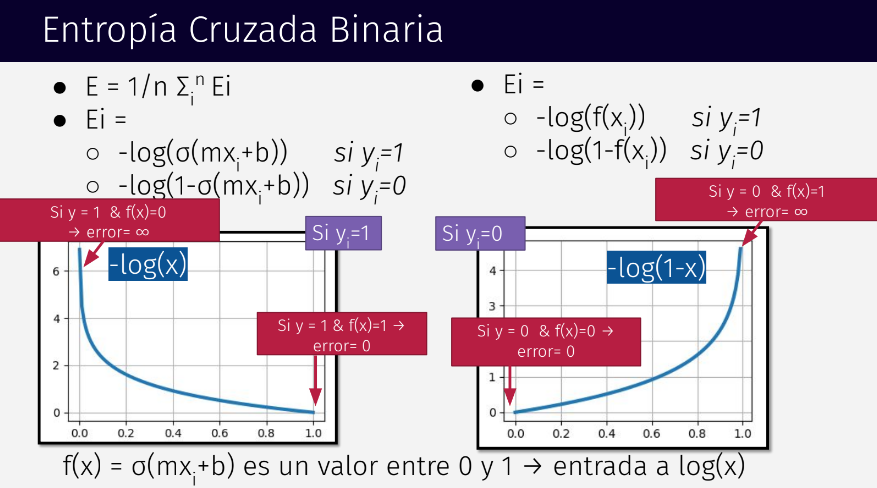

La **entropía cruzada binaria (Binary Cross-Entropy)** es una función de pérdida comúnmente utilizada en modelos de clasificación binaria, donde la salida esperada es una de dos clases (0 o 1). Mide la diferencia entre la distribución de probabilidad real (etiquetas verdaderas) y la distribución de probabilidad predicha por el modelo.

Matemáticamente, para una única probabilidad de predicción `p` y una etiqueta real `y` (donde `y` es 0 o 1), se define como:

`L = - (y * log(p) + (1 - y) * log(1 - p))`

- Si la etiqueta real `y` es 1, la pérdida se convierte en `-log(p)`. Cuanto más cerca esté `p` de 1, menor será la pérdida. Si `p` es 0, la pérdida tiende a infinito.
- Si la etiqueta real `y` es 0, la pérdida se convierte en `-log(1 - p)`. Cuanto más cerca esté `p` de 0, menor será la pérdida. Si `p` es 1, la pérdida tiende a infinito.

Esta función de pérdida penaliza fuertemente las predicciones incorrectas y es fundamental para entrenar redes neuronales en tareas como la clasificación 'sí/no' o 'verdadero/falso'.

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


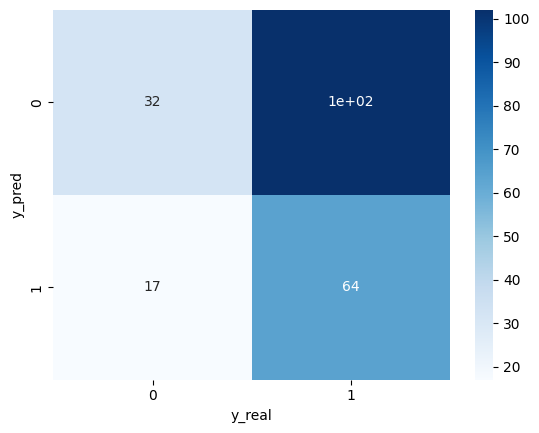

In [13]:
y_predic_ej1 = modelo_titanic_1.predict(ej1_x_test)
y_predic_cat_ej1 = np.where(y_predic_ej1>0.4,1,0)

ds_validacion=pd.DataFrame(y_predic_cat_ej1,ej1_y_test).reset_index()
ds_validacion.columns=['y_pred','y_real']

tabla=pd.crosstab(ds_validacion.y_pred, ds_validacion.y_real)
grf=sns.heatmap(tabla,annot=True, cmap = 'Blues')
plt.show()

### Data set Iris

In [14]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import OneHotEncoder, StandardScaler

iris = load_iris()

x = iris['data']
y = iris['target']
names = iris['target_names']
feature_names = iris['feature_names']

# Split the data set into training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.5,
                                                    stratify = y,
                                                    random_state=41)

# One hot encoding
enc = OneHotEncoder()
y_train_encoder = enc.fit_transform(y_train[:, np.newaxis]).toarray()
y_test_encoder = enc.transform(y_test[:, np.newaxis]).toarray()

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [15]:
# calcula la cantidad de clases
cant_clases=len(np.unique(y))

d_in=len(feature_names)
modelo_iris_1 = keras.Sequential([
    # input_shape solo en la primer capa
    # Capa con 3 salidas, activación relu
    keras.layers.Dense(2,input_shape=(d_in,), activation='relu',
                       kernel_initializer='uniform'),
    keras.layers.Dense(cant_clases, activation='softmax')])

modelo_iris_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (76.00 B)

 Trainable params: 19 (76.00 B)

 Non-trainable params: 0 (0.00 B)

En la última capa de la red neuronal se utiliza la función de activación **'softmax'**. Softmax toma las salidas numéricas de la capa anterior y las convierte en probabilidades, asegurándose de que la suma de todas las probabilidades para una entrada dada sea igual a 1. De esta manera, el modelo puede indicar la probabilidad de que una flor pertenezca a cada una de las tres clases (Setosa, Versicolor o Virginica).


Para problemas de clasificación con más de dos clases, como el conjunto de datos Iris que tiene tres tipos de flores, utilizamos **'categorical_crossentropy'** como función de pérdida. Esta función es ideal para medir la diferencia entre las probabilidades predichas por el modelo y las etiquetas reales en un formato 'one-hot encoded'.


In [ ]:
modelo_iris_1.compile(
  optimizer=keras.optimizers.SGD(learning_rate=0.001),
  loss='categorical_crossentropy',
  # metricas para ir calculando en cada iteracion o batch
  metrics=['AUC'],
)

cant_epochs=50000

historia_modelo_iris_1=modelo_iris_1.fit(x_train_scaled,
                                         y_train_encoder,
                                         epochs=cant_epochs,
                                         batch_size=16,
                                         validation_split=0.2,
                                         verbose=True)

Streaming output truncated to the last 5000 lines.
Epoch 2501/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - AUC: 0.9874 - loss: 0.3144 - val_AUC: 0.9378 - val_loss: 0.4595
Epoch 2502/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - AUC: 0.9874 - loss: 0.3143 - val_AUC: 0.9378 - val_loss: 0.4594
Epoch 2503/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - AUC: 0.9874 - loss: 0.3142 - val_AUC: 0.9378 - val_loss: 0.4593
Epoch 2504/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - AUC: 0.9874 - loss: 0.3141 - val_AUC: 0.9378 - val_loss: 0.4592
Epoch 2505/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - AUC: 0.9874 - loss: 0.3140 - val_AUC: 0.9378 - val_loss: 0.4591
Epoch 2506/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - AUC: 0.9874 - loss: 0.3139 - val_AUC: 0.9378 - val_loss: 0.4590
Epoch 2507/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - AUC: 0.9874 - loss: 0.3138 - val_AUC: 0.9378 - val_loss: 0.4589
Epoch 2508/5000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - AUC: 0.9874 - loss: 0.3138 - val_AUC: 0.9378 - val_lo

In [ ]:
y_predic_iris = modelo_iris_1.predict(x_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [ ]:
y_predic_iris.shape

(75, 3)

In [ ]:
y_predic_iris[0:10]

array([[9.72478390e-01, 2.73844209e-02, 1.37134615e-04],
       [9.85174537e-01, 1.47736305e-02, 5.18160705e-05],
       [9.90326524e-01, 9.64682456e-03, 2.65131639e-05],
       [9.79951918e-01, 1.99647546e-02, 8.32646474e-05],
       [9.55849528e-01, 4.38611172e-02, 2.89456628e-04],
       [9.93582666e-01, 6.40329765e-03, 1.39341446e-05],
       [9.96322691e-01, 3.67139536e-03, 5.82498978e-06],
       [9.92134035e-01, 7.84685463e-03, 1.91704730e-05],
       [1.48202395e-02, 1.36789009e-01, 8.48390758e-01],
       [9.88169074e-01, 1.17944526e-02, 3.63604013e-05]], dtype=float32)

In [ ]:
y_predic_iris_clases=np.argmax(y_predic_iris,axis=1).tolist()
y_real_iris_clases=np.argmax(y_test_encoder,axis=1).tolist()

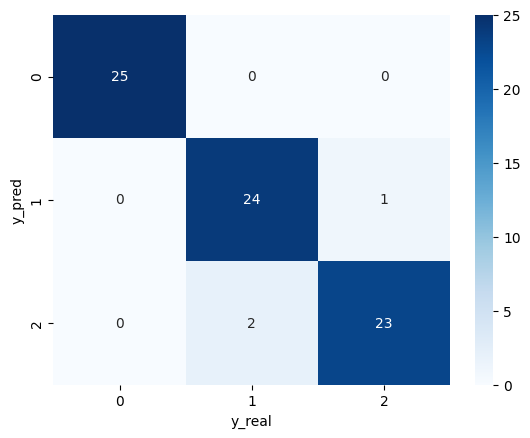

In [ ]:
ds_validacion_iris=pd.DataFrame(y_predic_iris_clases,y_real_iris_clases).reset_index()
ds_validacion_iris.columns=['y_pred','y_real']

tabla_iris=pd.crosstab(ds_validacion_iris.y_pred, ds_validacion_iris.y_real)
grf=sns.heatmap(tabla_iris,annot=True, cmap = 'Blues')
plt.show()

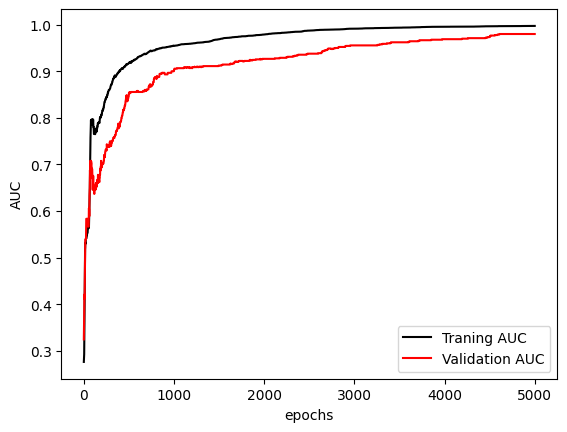

In [ ]:
epochs = range(cant_epochs)

plt.plot(epochs, historia_modelo_iris_1.history['AUC'], color='black', label='Traning AUC')
plt.plot(epochs, historia_modelo_iris_1.history['val_AUC'], color='red', label='Validation AUC')
plt.xlabel("epochs")
plt.ylabel("AUC")
plt.legend()

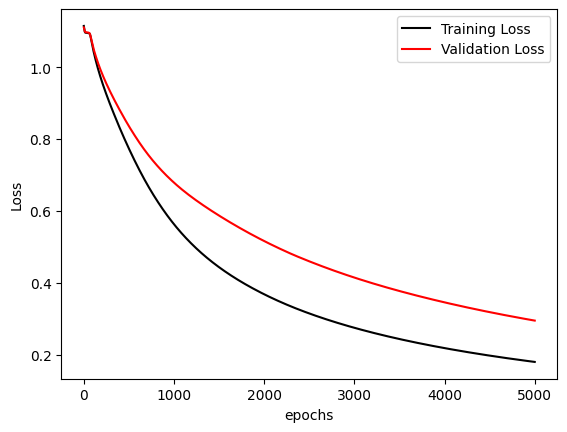

In [ ]:
epochs = range(cant_epochs)

plt.plot(epochs, historia_modelo_iris_1.history['loss'], color='black', label='Training Loss')
plt.plot(epochs, historia_modelo_iris_1.history['val_loss'], color='red', label='Validation Loss')
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.legend()

Las evolución de la loss a lo largo de las epochs nos pueden ayudar a identificar problemas como sobreajuste (overfitting) o subajuste (underfitting).

La siguiente imagen ilustra diferentes escenarios de sobreajuste al comparar la pérdida en entrenamiento (línea sólida) y validación (línea punteada) a lo largo de las iteraciones. Este gráfico fue extraído del libro Deep Learning with PyTorch de Eli Stevens, Luca Antiga y Thomas Viehmann (©2020, Manning Publications Co., todos los derechos reservados).

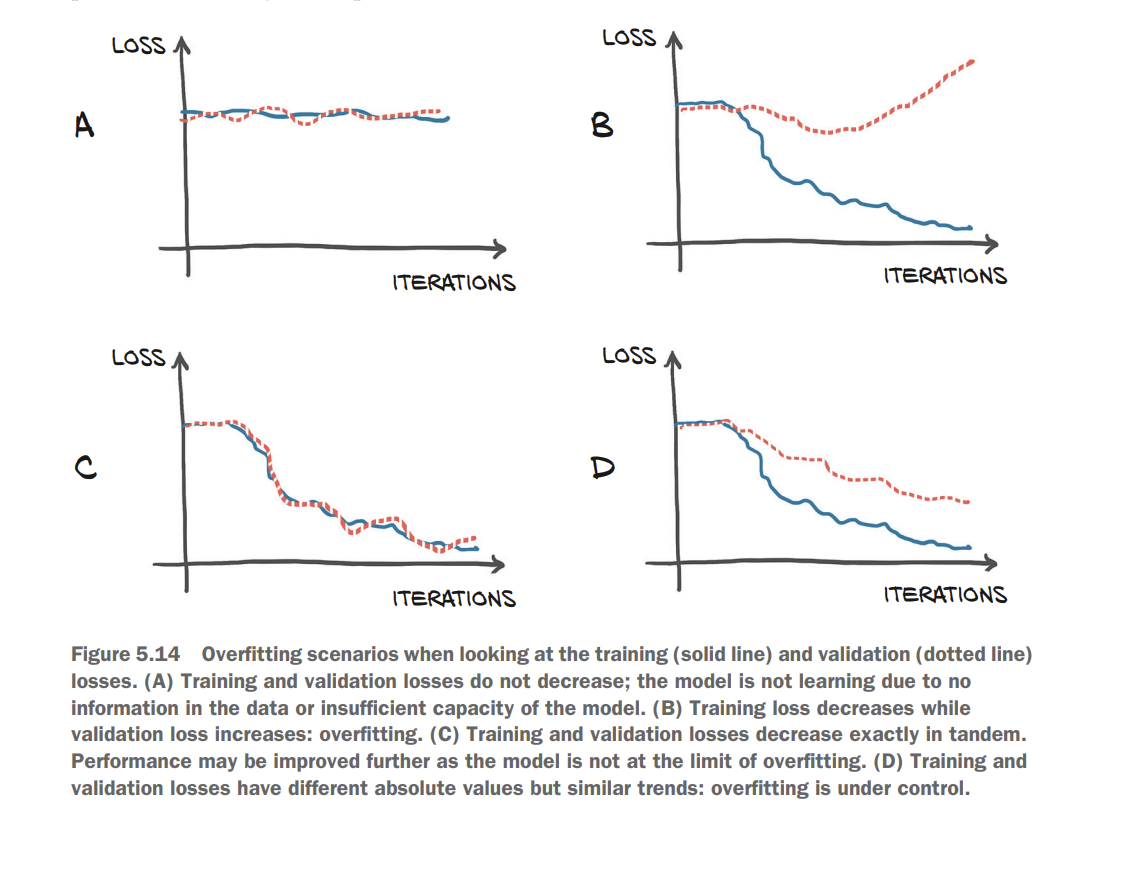